In [1]:
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
def load_csv_files(start_year=2004, end_year=2004):
    """
    Loads the indication-reaction, indication-drug, and drug-reaction association CSV files into Pandas DataFrames.

    Parameters:
        start_year (int): The start year of the dataset.
        end_year (int): The end year of the dataset.

    Returns:
        tuple: (ind_rea_df, ind_drug_df, drug_rea_df)
    """
    # Define directory path
    results_dir = f'../results/{start_year}-{end_year}'

    confounders = {
        'ind': 'indication',
        'drug': 'drug',
        'sex': 'sex',
        'age': 'age'
    }
    file_paths = dict()
    for ccode, cname in confounders.items():
        file_paths[f"{ccode}_rea_df"] = f"{cname}_reaction_associations.csv"
        file_paths[f"{ccode}_drug_df"] = f"{cname}_drug_associations.csv"
    
    dfs = dict()
    for dfkey, filename in file_paths.items():
        file_path = os.path.join(results_dir, filename)
        # Load CSVs into DataFrames
        try:
            dfs[dfkey] = pd.read_csv(file_path)
            print(f"Loaded {len(dfs[dfkey])} rows from {file_path}. Stored at key: {dfkey}")
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
            dfs[dfkey] = None

    return dfs

In [37]:
def confounder_drug_reaction_correlation(
    ind_rea_df, ind_drug_df, drug_rea_df, 
    conf_rea_threshold=100, min_threshold_for_drug=40, num_bins=30, type='proportion',
    conf_rea_col = 'PRR', conf_drug_col = 'PHI', drug_rea_col = 'PRR',
    conf_col_name='indication', title=None, newfig=True, color='k', label=None
):
    """
    Plots:
    - X-axis: Average PHI (conf_drug_col) in equally sized bins of drugs.
    - Y-axis: Mean (or Proportion of drugs in each bin with statistic (drug_rea_col) > min_threshold_for_drug) for the indication's reactions.

    Parameters:
        ind_rea_df (pd.DataFrame): DataFrame with confounder-reaction associations. Initially implemented with indications, but can be other things.
        ind_drug_df (pd.DataFrame): DataFrame with confounder-drug associations. Initiatlly implemented with indications, but can be other things. 
        drug_rea_df (pd.DataFrame): DataFrame with drug-reaction associations.
        ind_rea_threshold (float): Threshold for identifying strong confounder-reaction links. Note used if type == 'mean'
        min_threshold_for_drug (float): PRR threshold for drugs.
        num_bins (int): Number of bins to group drugs based on PHI.
        type (str): 'proportion' or 'mean' to indicate to plot proportion above threshold or mean.
        conf_col (str): Which reaction association statistic to use in the confounder matrix. 
        drug_col (str): which reaction association statistic to use in the drug matrix.
        title (str): override the title

    Returns:
        data (pd.DataFrame): DataFrame with possibly confounded drug-reaction associations.
    """
    
    indication_reactions = ind_rea_df[ind_rea_df[conf_rea_col]>conf_rea_threshold]
    
    data = None
    for ind in indication_reactions[conf_col_name].unique():
        relevant_reactions = list(set(indication_reactions[indication_reactions[conf_col_name] == ind]["reaction"]))
        id = ind_drug_df[ind_drug_df[conf_col_name]==ind]
        dr = drug_rea_df[drug_rea_df['reaction'].isin(relevant_reactions)]
        re = id.merge(dr, on="drug", suffixes=['_conf_drug', '_drug_rea'])[[conf_col_name, 'reaction', 'drug', f'{conf_drug_col}_conf_drug', f'{drug_rea_col}_drug_rea']]
        if data is None:
            data = re
        else:
            data = pd.concat([data, re], ignore_index=True)

    sorted_data = data.sort_values(by=f'{conf_drug_col}_conf_drug')

    plot_data = list()
    for b, df in enumerate(np.array_split(sorted_data, num_bins)):
        yprop = (df[f'{drug_rea_col}_drug_rea'] > min_threshold_for_drug).sum()/df[f'{drug_rea_col}_drug_rea'].shape[0]
        ymu = df[f'{drug_rea_col}_drug_rea'].mean()
        xmu = df[f'{conf_drug_col}_conf_drug'].mean()
        #print(b, xmu, ymu, yprop)
        plot_data.append((xmu, ymu, yprop))

    x, ymu, yprop = zip(*plot_data)
    if type == 'proportion':
        y = yprop
        ylabel = f"Proportion of Drugs with {drug_rea_col} > {min_threshold_for_drug}"
    elif type == 'mean':
        y = ymu
        ylabel = f"Average {drug_rea_col}"
    else:
        raise Exception(f"Unknown type provided: {type}")
    
    if newfig:
        plt.figure(figsize=(4, 3))
    plt.scatter(x,y,color=color, label=label)

    plt.xlabel(f"Average {conf_drug_col} in Bin")
    plt.ylabel(ylabel)
    if title is not None:
        plt.title(title)
    else:
        plt.title(f"Drug-{conf_col_name.title()} Correlation vs. Drug-Reaction Proportion (Binned)")

    plt.grid(True, linestyle='--', alpha=0.5)
    # plt.show()

    return data


In [18]:
# Load DataFrames
start_year = 2004
end_year = 2004
dfs = load_csv_files(start_year, end_year)

Loaded 11217 rows from ../results/2004-2004/indication_reaction_associations.csv. Stored at key: ind_rea_df
Loaded 17118 rows from ../results/2004-2004/indication_drug_associations.csv. Stored at key: ind_drug_df
Loaded 38092 rows from ../results/2004-2004/drug_reaction_associations.csv. Stored at key: drug_rea_df
Loaded 32765 rows from ../results/2004-2004/drug_drug_associations.csv. Stored at key: drug_drug_df
Loaded 7202 rows from ../results/2004-2004/sex_reaction_associations.csv. Stored at key: sex_rea_df
Loaded 447 rows from ../results/2004-2004/sex_drug_associations.csv. Stored at key: sex_drug_df
Loaded 9831 rows from ../results/2004-2004/age_reaction_associations.csv. Stored at key: age_rea_df
Loaded 1115 rows from ../results/2004-2004/age_drug_associations.csv. Stored at key: age_drug_df


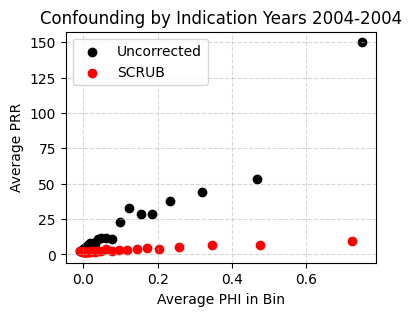

In [41]:
indications = confounder_drug_reaction_correlation(
    dfs['ind_rea_df'],  # DataFrame for confounder-reaction links
    dfs['ind_drug_df'], # DataFrame for confounder-drug links
    dfs['drug_rea_df'], # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=40,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='indication', # name of confounder
    title = f'Confounding by Indication Years {start_year}-{end_year}',
    label='Uncorrected'
)

psm_10_5_df = pd.read_csv('../results/2004-2004/hdpsm_nrep10_mratio5_drug_reaction_associations.csv')
psm_10_5_df.head()

rep0 = psm_10_5_df[psm_10_5_df['replicate']==0]

_ = confounder_drug_reaction_correlation(
    dfs['ind_rea_df'],  # DataFrame for confounder-reaction links
    dfs['ind_drug_df'], # DataFrame for confounder-drug links
    rep0, # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=40,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='indication', # name of confounder
    title = f'Confounding by Indication Years {start_year}-{end_year}',
    newfig=False, color='red', label='SCRUB'
)
plt.legend()

In [28]:
indications.sort_values(by='PRR_drug_rea', ascending=False).head(20)

,indication,reaction,drug,PHI_conf_drug,PRR_drug_rea
2736,CONTRACEPTION,MEDICAL DEVICE DISCOMFORT,etonogestrel,0.779088,6992.496357
2721,CONTRACEPTION,MEDICAL DEVICE DISCOMFORT,ethinyl estradiol,0.753361,5609.328404
3744,ECZEMA,APPLICATION SITE DRYNESS,pimecrolimus,0.714252,4527.821615
2746,CONTRACEPTION,WITHDRAWAL BLEEDING IRREGULAR,etonogestrel,0.779088,3750.165644
3679,DRUG USE FOR UNKNOWN INDICATION,LIVE BIRTH,isotretinoin,0.149769,3202.692555
2733,CONTRACEPTION,WITHDRAWAL BLEEDING IRREGULAR,ethinyl estradiol,0.753361,3008.354898
4486,HODGKIN'S DISEASE,AZOOSPERMIA,vinblastine,0.511226,2706.760563
643,ANTIVIRAL PROPHYLAXIS,RESPIRATORY SYNCYTIAL VIRUS INFECTION,palivizumab,0.702043,2482.011743
50,ABORTION INDUCED,ABORTION INCOMPLETE,misoprostol,0.238401,2457.551708
4501,HORMONE REPLACEMENT THERAPY,BREAST OPERATION,"estrogens, conjugated (USP)",0.804327,1632.031589


(24884, 5)

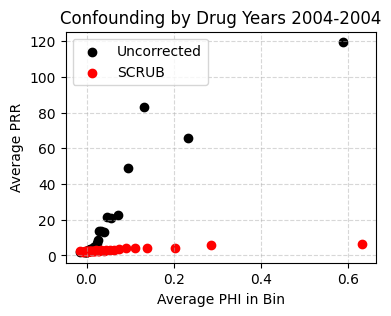

In [40]:
conf_drug_rea_df = dfs['drug_rea_df'].copy()
conf_drug_rea_df.rename(columns={'drug': 'conf_drug'}, inplace=True)

drugs = confounder_drug_reaction_correlation(
    conf_drug_rea_df,  # DataFrame for confounder-reaction links
    dfs['drug_drug_df'], # DataFrame for confounder-drug links
    dfs['drug_rea_df'], # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=40,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='conf_drug', # name of confounder
    title = f'Confounding by Drug Years {start_year}-{end_year}',
    label='Uncorrected'
)

_ = confounder_drug_reaction_correlation(
    conf_drug_rea_df,  # DataFrame for confounder-reaction links
    dfs['drug_drug_df'], # DataFrame for confounder-drug links
    rep0, # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=40,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='conf_drug', # name of confounder
    title = f'Confounding by Drug Years {start_year}-{end_year}',
    newfig=False, color='red', label='SCRUB'
)
plt.legend()
drugs.shape

In [30]:
drugs.sort_values(by='PRR_drug_rea', ascending=False).head(20)

,conf_drug,reaction,drug,PHI_conf_drug,PRR_drug_rea
7110,etonogestrel,MEDICAL DEVICE DISCOMFORT,ethinyl estradiol,0.895652,5609.328404
19883,povidone-iodine,ENDOPHTHALMITIS,magnesium chloride,0.362760,3666.033206
14784,lidocaine,ENDOPHTHALMITIS,magnesium chloride,0.117509,3666.033206
21731,sodium citrate,ENDOPHTHALMITIS,magnesium chloride,0.786187,3666.033206
19871,potassium chloride,ENDOPHTHALMITIS,magnesium chloride,0.135970,3666.033206
6516,epinephrine,ENDOPHTHALMITIS,magnesium chloride,0.119640,3666.033206
21698,sodium chloride,ENDOPHTHALMITIS,magnesium chloride,0.258775,3666.033206
21646,sodium acetate,ENDOPHTHALMITIS,magnesium chloride,0.769767,3666.033206
2794,calcium chloride,ENDOPHTHALMITIS,magnesium chloride,0.498876,3666.033206
15446,magnesium chloride,ENDOPHTHALMITIS,sodium citrate,0.786187,3413.170036


(32, 5)

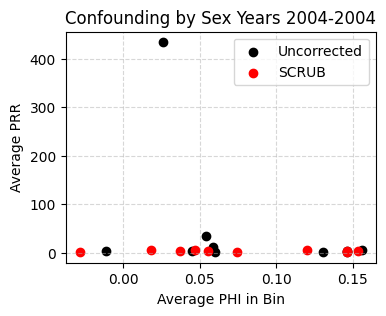

In [39]:
sexes = confounder_drug_reaction_correlation(
    dfs['sex_rea_df'],  # DataFrame for confounder-reaction links
    dfs['sex_drug_df'], # DataFrame for confounder-drug links
    dfs['drug_rea_df'], # DataFrame for drug-reaction links
    conf_rea_threshold=30,  # Identify strong indication-reaction links
    min_threshold_for_drug=None,  # Threshold for PRR in drugs
    num_bins=10, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='sex', # name of confounder
    title = f'Confounding by Sex Years {start_year}-{end_year}',
    label='Uncorrected'
)

_ = confounder_drug_reaction_correlation(
    dfs['sex_rea_df'],  # DataFrame for confounder-reaction links
    dfs['sex_drug_df'], # DataFrame for confounder-drug links
    rep0, # DataFrame for drug-reaction links
    conf_rea_threshold=30,  # Identify strong indication-reaction links
    min_threshold_for_drug=None,  # Threshold for PRR in drugs
    num_bins=10, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='sex', # name of confounder
    title = f'Confounding by Sex Years {start_year}-{end_year}',
    newfig=False, color='red', label='SCRUB'
)
plt.legend()
sexes.shape

In [32]:
# sexes.sort_values(by='PRR_drug_rea', ascending=False).head(20)

(134, 5)

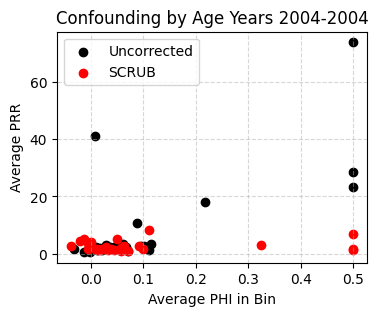

In [38]:
ages = confounder_drug_reaction_correlation(
    dfs['age_rea_df'],  # DataFrame for confounder-reaction links
    dfs['age_drug_df'], # DataFrame for confounder-drug links
    dfs['drug_rea_df'], # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=None,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='age', # name of confounder
    title = f'Confounding by Age Years {start_year}-{end_year}',
    label='Uncorrected'
)

_ = confounder_drug_reaction_correlation(
    dfs['age_rea_df'],  # DataFrame for confounder-reaction links
    dfs['age_drug_df'], # DataFrame for confounder-drug links
    rep0, # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=None,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_col_name='age', # name of confounder
    title = f'Confounding by Age Years {start_year}-{end_year}',
    label='SCRUB',
    newfig=False, color='red'
)
plt.legend()
ages.shape

In [35]:
ages.sort_values(by='PRR_drug_rea', ascending=False).head(20)

,age,reaction,drug,PHI_conf_drug,PRR_drug_rea
0,Middle,BLOOD HUMAN CHORIONIC GONADOTROPIN INCREASED,thalidomide,0.009333,199.920018
30,Younger,PRESCRIBED OVERDOSE,atomoxetine,0.499065,122.260455
29,Younger,NEGATIVISM,atomoxetine,0.499065,95.298073
33,Younger,TIC,atomoxetine,0.499065,64.473264
23,Younger,EDUCATIONAL PROBLEM,atomoxetine,0.499065,47.649037
31,Younger,PSYCHOMOTOR HYPERACTIVITY,atomoxetine,0.499065,41.597790
80,Younger,BENIGN INTRACRANIAL HYPERTENSION,isotretinoin,0.089313,37.901687
26,Younger,IMPULSE-CONTROL DISORDER,atomoxetine,0.499065,35.577947
22,Younger,ATTENTION DEFICIT/HYPERACTIVITY DISORDER,atomoxetine,0.499065,32.673625
32,Younger,RETCHING,atomoxetine,0.499065,31.121496
